In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import os
os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'
import random

### code 

In [2]:

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._parant:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


In [3]:
class Value:
    def __init__(self, data ,label= '', _childrens= [], _op= '' ,momentum= 0.0 , velocity=0.0):
        self.data = data
        self.label = label
        self._parant = list(_childrens)
        self.grad = 0.0
        self._op = _op
        self._backward = lambda : None
        self.momentum = momentum
        self.velocity = velocity

    ###Operations
    def __add__(self, other):
        other = other if isinstance(other , Value) else Value(other)
        out = Value(self.data + other.data , _childrens=[self ,other] , _op = "+")

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward =_backward

        return out

    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out  =  Value(self.data * other.data , _childrens=[self,other], _op = '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def __pow__(self, other):
        other = other if isinstance(other , (int , float)) else  'power function is only aplicable on an int or float value of power'
        out = Value(self.data ** other , _childrens=[self] ,_op = '**k')

        def _backward():
            self.grad += (other * (self.data ** (other -1))) * out.grad
        out._backward = _backward

        return out
    
    def __truediv__(self, other):
        return self * (other ** -1)

    
    def __sub__(self, other):
        return self + (-other)
    
    def __neg__(self):
        return -1.0 * self

    
    ###ReOperations
    def __radd__(self, other): # other + self 
        return self + other
    
    def __rsub__(self, other): # other - self
        return (-self) + other
    
    def __rmul__(self, other): # other * self
        return self * other
    
    def __rtruediv__(self, other): # other /self
        return self / other
    
    ## Functions like tanh()
    def tanh(self):
        num = math.exp(self.data) - math.exp(-self.data)
        deno = math.exp(self.data) + math.exp(-self.data)
        tanh =num/deno
        out = Value(tanh , _childrens=[self], _op = 'tanh')

        def _backward():
            tanh_grad = 1 - out.data **2
            self.grad += tanh_grad * out.grad
        out._backward = _backward

        return out 

    
    def relu(self):
        out = Value(self.data if self.data > 0 else 0 , _childrens=[self] , _op = 'relu')

        def _backward():
            self.grad += (1.0 * out.grad) if self.data > 0 else 0

        out._backward = _backward
        return out    

    ## Backpropagation fn backward()
    def backward(self):
        self.grad = 1.0
        value = self.grad
        val_list  = []
        def gen_val_list(v):
            if v not in val_list:
                for child in v._parant:
                    gen_val_list(child)
                val_list.append(v)
                
        gen_val_list(self)
        for val in reversed(val_list):
            val._backward()



    
    def __repr__(self):
        return f'Value(data= {self.data})'

In [429]:
class Value:
    def __init__(self, data ,label= '', _childrens= [], _op= '' ,momentum= 0.0 , velocity=0.0):
        self.data = data
        self.label = label
        self._parant = list(_childrens)
        self.grad = 0.0
        self._op = _op
        self._backward = lambda : None
        self.momentum = momentum
        self.velocity = velocity

    ###Operations
    def __add__(self, other):
        other = other if isinstance(other , Value) else Value(other)
        out = Value(self.data + other.data , _childrens=[self ,other] , _op = "+")

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward =_backward

        return out

    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out  =  Value(self.data * other.data , _childrens=[self,other], _op = '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def __pow__(self, other):
        other = other if isinstance(other , (int , float)) else  'power function is only aplicable on an int or float value of power'
        out = Value(self.data ** other , _childrens=[self] ,_op = '**k')

        def _backward():
            self.grad += (other * (self.data ** (other -1))) * out.grad
        out._backward = _backward

        return out
    
    def __truediv__(self, other):
        return self * (other ** -1)

    
    def __sub__(self, other):
        return self + (-other)
    
    def __neg__(self):
        return -1.0 * self

    
    ###ReOperations
    def __radd__(self, other): # other + self 
        return self + other
    
    def __rsub__(self, other): # other - self
        return (-self) + other
    
    def __rmul__(self, other): # other * self
        return self * other
    
    def __rtruediv__(self, other): # other /self
        return self / other
    
    ## Functions like tanh()
    def tanh(self):
        if self.data >= 0:
            z = math.exp(-2.0 * self.data)
            tanh_val = (1.0 - z) / (1.0 + z)
        # If self.data is negative, calculate using positive exponents (safe since data is neg)
        else:
            z = math.exp(2.0 * self.data)
            tanh_val = (z - 1.0) / (z + 1.0)
        # num = math.exp(self.data) - math.exp(-self.data)
        # deno = math.exp(self.data) + math.exp(-self.data)
        # tanh =num/deno
        out = Value(tanh_val , _childrens=[self], _op = 'tanh')

        def _backward():
            tanh_grad = 1 - out.data **2
            self.grad += tanh_grad * out.grad
        out._backward = _backward

        return out 

    # ## Functions like tanh()
    # def tanh(self):
    #     num = math.exp(self.data) - math.exp(-self.data)
    #     deno = math.exp(self.data) + math.exp(-self.data)
    #     tanh =num/deno
    #     out = Value(tanh , _childrens=[self], _op = 'tanh')

    #     def _backward():
    #         tanh_grad = 1 - out.data **2
    #         self.grad += tanh_grad * out.grad
    #     out._backward = _backward

    #     return out 

    
    def relu(self):
        out = Value(self.data if self.data > 0 else 0 , _childrens=[self] , _op = 'relu')

        def _backward():
            self.grad += (1.0 * out.grad) if self.data > 0 else 0

        out._backward = _backward
        return out    

    ## Backpropagation fn backward()
    def backward(self):
        self.grad = 1.0
        value = self.grad
        val_list  = []
        def gen_val_list(v):
            if v not in val_list:
                for child in v._parant:
                    gen_val_list(child)
                val_list.append(v)
                
        gen_val_list(self)
        for val in reversed(val_list):
            val._backward()



    
    def __repr__(self):
        return f'Value(data= {self.data})'

In [430]:
# a = Value(3.0)
# b = Value(2.0)
# c = a + b
# d  = a * c
# e = d **2
# f = 2 ** e
# f.backward()

# f,e,d,c


In [463]:
class Neuron:
    def __init__(self , nin):
        self.weights = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.bias = Value(random.uniform(-1,1))

    def __call__(self ,X):
        out = sum([(w*x) for w ,x in zip(self.weights ,X) ],start=self.bias)
        out = out.tanh()
        return out

    def parameters(self):
        return self.weights + [self.bias]
    
    def __repr__(self):
        return f'Neuron(weights = {self.weights}, bias= {self.bias})'

In [464]:
class Layer:
    def __init__(self , nin , nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        params = []
        for n in self.neurons:
            params += n.parameters()

        return params

        # return [n.parameters() for n in self.neurons]
        
    def __repr__(self):
        return f"Layer(neurons= {self.neurons})"

In [465]:
class MLP:
    def __init__(self, nin , nouts: list):
        all = [nin] + nouts
        self.layers = [Layer(all[i] , all[i+1]) for i in range(len(all) -1)]
        
    def __call__(self, x : list):
        for l in self.layers:
            x = l(x)
        return x
    
    def zero_grad(self):
        for n in self.parameters():
            n.grad = 0.0
    
    def parameters(self) -> list[Value]:
        params  = []
        for lay in self.layers:
            params += lay.parameters()
        return params
    
    def __repr__(self):
        return f"MLP(layers={self.layers})"

### test

In [466]:
class Loss:
    def __init__(self, mlp : MLP ,xs , ys):
        self.mlp = mlp 
        self.xs = xs
        self.ys = ys
        self.lr = 0.1
        self.loss_history = []

    def __call__(self, lr = 0.1 ,iterations = 20):
        last_loss = 0
        mlp = self.mlp
        self.lr = lr
        self.t = 0
        
        

        for _ in range(iterations):
            if self.t > 100:
                self.t = 0
                
            y_pred = [mlp(x) for x in self.xs]
            loss  = sum((y_p - y_a)**2 for y_p , y_a in zip(y_pred , self.ys))
            self.loss_history.append(loss.data)

            for  n  in mlp.parameters():
                n.grad = 0.0
            
            loss.backward()

            self.adam(mlp)
            last_loss = loss.data

        return last_loss , y_pred
    
    def adam(self, mlp: MLP, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for n in mlp.parameters():
            n.momentum = n.momentum * beta1 + (2 - beta1) * n.grad
            n.velocity = (beta2 * n.velocity) + (2 - beta2) * (n.grad **2)

            n.momentum = n.momentum/(2 - beta1**self.t)
            n.velocity = n.velocity/(2 - beta2**self.t)

            n.data += -(self.lr * n.momentum)/math.sqrt(n.velocity + eps)



    def SGD(self , mlp:MLP) -> None:

        for n in mlp.parameters():
            n.data += -self.lr * n.grad

    
    def momentum(self , mlp : MLP , beta1=0.9) -> None:
        
        for n in mlp.parameters():
            n.momentum = n.momentum * beta1 + (1 - beta1) * n.grad
            n.data += -(self.lr * n.momentum)

    def RMSprop(self, mlp : MLP ,beta2=0.99, eps=1e-8) -> None:

        for n in mlp.parameters():
            n.velocity = (beta2 * n.velocity) + (1 - beta2) * (n.grad **2)
            n.data += -(self.lr * n.grad)/(math.sqrt(n.velocity + eps))

        

In [491]:
xs = [
    [0.0021, 1300.0],    # A: clean XOR, same sign -> -1.0
    [-0.0016, -950.0],   # A: clean XOR, same sign -> -1.0
    [0.0027, -1120.0],   # A: clean XOR, diff sign -> 1.0
    [-0.0031, 1080.0],   # A: clean XOR, diff sign -> 1.0

    [0.00005, 8.0],       # B: near-zero magnitudes, same sign -> -1.0
    [-0.00004, -6.0],     # B: near-zero magnitudes, same sign -> -1.0
    [0.00003, -5.0],      # B: near-zero magnitudes, diff sign -> 1.0

    [0.0022, 50000.0],    # C: huge outlier in x2 -> -1.0
    [-3200.0, -0.0035],   # C: huge outlier in x1 (no column shortcut) -> -1.0

    [0.0027, -1120.0],    # D: exact duplicate of row 3 -> 1.0
    [0.0028, -1125.0],    # D: near-duplicate of row 3, MISLABELED -> -1.0
]
ys = [-1.0, -1.0, 1.0, 1.0, -1.0, -1.0, 1.0, -1.0, -1.0, 1.0, -1.0]

m_adam = MLP(2, [8, 8, 1])   # a little more capacity helps escape the XOR saddle
loss = Loss(m_adam, xs, ys)
loss(iterations=50, lr=0.01)

(8.766692316628104,
 [Value(data= -0.4663989705038221),
  Value(data= -0.08009540747399743),
  Value(data= -0.08009540747399743),
  Value(data= -0.4663989705038221),
  Value(data= -0.5845655024736899),
  Value(data= 0.07181094431187396),
  Value(data= 0.18003617248340079),
  Value(data= -0.4663989705038221),
  Value(data= -0.834048317683577),
  Value(data= -0.08009540747399743),
  Value(data= -0.08009540747399743)])

In [ ]:

# xs = [
#   [2.0, 3.0, -1.0],
#   [3.0, -1.0, 0.5],
#   [0.5, 1.0, 1.0],
#   [1.0, 1.0, -1.0],
# ]
# ys = [1.0, -1.0, -1.0, 1.0] # desired targets
# m = MLP(3, [3,3,1])

# Inputs: [x0, x1] (Points in 2D space)
# xs = [
#     [0.1, 0.1],     # Very close to center -> Positive
#     [-0.1, -0.2],   # Very close to center -> Positive
#     [0.2, -0.1],    # Close to center -> Positive
#     [0.7, 0.7],     # Far from center -> Negative
#     [-0.8, 0.6],    # Far from center -> Negative
#     [1.2, -1.1],    # Very far -> Negative
#     [-1.5, 1.3]     # Very far -> Negative
# ]

# ys = [1.0, 1.0, 1.0, -1.0, -1.0, -1.0, -1.0] # Targets


# xs = [
#     [-1.0, 0.0],   # Wave 1 (Class 1.0)
#     [-0.5, 0.5],   # Wave 1
#     [0.0, 0.5],    # Wave 1
#     [0.5, 0.0],    # Wave 1 
#     [1.0, -0.5],   # Wave 1 
    
#     [-0.5, -0.5],  # Wave 2 (Class -1.0)
#     [0.0, -0.5],   # Wave 2
#     [0.5, -0.5],   # Wave 2 (Contradiction resolved! Shifted down to -0.5)
#     [1.0, 0.5],    # Wave 2 
#     [1.5, 0.0]     # Wave 2
# ]

# ys = [1.0, 1.0, 1.0, 1.0, 1.0, -1.0, -1.0, -1.0, -1.0, -1.0]
# --- THE ILL-CONDITIONED VALLEY DATASET ---
# Input features have wildly different scales (X1 is tiny, X2 is massive)
xs = [
    [0.001, 1000.0],  # Target: 1.0
    [-0.002, -500.0], # Target: -1.0
    [0.003, 1200.0],  # Target: 1.0
    [-0.001, -900.0]  # Target: -1.0
]
ys = [1.0, -1.0, 1.0, -1.0]

m_sgd = MLP(2, [6, 6, 1]) # 2 inputs, two hidden layers of 6, 1 output
loss = Loss(m_sgd, xs, ys)
loss(iterations=200 ,lr=0.01)


In [436]:
# # loss = Loss(m, xs ,ys)

# m = MLP(2, [4, 4, 1]) # 2 inputs, two hidden layers of 4, 1 output
# loss = Loss(m, xs, ys)
m_sgd = MLP(2, [6, 6, 1]) # 2 inputs, two hidden layers of 6, 1 output
loss = Loss(m_sgd, xs, ys)

In [437]:
loss(iterations=200 ,lr=0.01)

(0.0007532624140122596,
 [Value(data= 0.9860641770047084),
  Value(data= -0.9864935554474898),
  Value(data= 0.9860641770047084),
  Value(data= -0.9864935554474898)])

In [492]:
loss_history =loss.loss_history

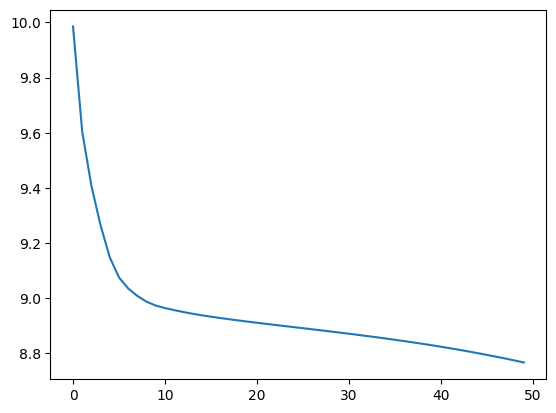

In [493]:
plt.plot(loss_history )
plt.show()

In [447]:
import math

# 1. Initialize your model 
# (Make sure your Parameter/Value class initializes n.momentum = 0.0 and n.velocity = 0.0)
m_model = MLP(2, [4, 1])

# 2. Instantiate the loss class with our skewed dataset
loss_tester = Loss(m_model, xs, ys)

# 3. Test SGD first (It will either blow up or do nothing)
print("--- RUNNING WITH SGD ---")
# To swap to SGD inside your class temporarily, change self.adam(mlp) to self.SGD(mlp)
final_loss_sgd, preds_sgd = loss_tester(lr=0.0001, iterations=50)
print(f"Final SGD Loss: {final_loss_sgd:.4f}\n")

# 4. Reset parameters and Test Corrected Adam
for n in m_model.parameters():
    n.data = random.uniform(-1, 1) # Reset weights
    n.momentum = 0.0
    n.velocity = 0.0

print("--- RUNNING WITH CORRECTED ADAM ---")
# Ensure you updated the (1 - beta**t) correction inside your class!
final_loss_adam, preds_adam = loss_tester(lr=0.1, iterations=50)
print(f"Final Adam Loss: {final_loss_adam:.4f}")

--- RUNNING WITH SGD ---
Final SGD Loss: 14.8344

--- RUNNING WITH CORRECTED ADAM ---
Final Adam Loss: 9.0030


In [420]:
import numpy as np
import math

# --- 1. CONSTRUCT THE PATHOLOGICAL DATASET ---
# A sequence of targets where a massive shift happens predictably but rarely
ys = [0.0] * 9 + [10.0]  # 9 small targets, 1 massive target

class ScalarParameter:
    def __init__(self, value):
        self.data = value
        self.grad = 0.0

# Initialize two identical parameters for both optimizers
w_adam = ScalarParameter(2.0)
w_amsgrad = ScalarParameter(2.0)

# --- 2. OPTIMIZER DICTIONARIES (STATE) ---
adam_state = {"m": 0.0, "v": 0.0, "t": 0}
amsgrad_state = {"m": 0.0, "v": 0.0, "v_max": 0.0, "t": 0}

# Hyperparameters (deliberately chosen to expose Adam's memory flaw)
lr = 0.1
beta1 = 0.9
beta2 = 0.99
eps = 1e-8

print(f"{'Step':<6} | {'Target':<6} | {'Adam W':<10} | {'AMSGrad W':<10}")
print("-" * 45)

# --- 3. THE SIMULATION LOOP ---
# We loop through the data points sequentially to simulate online/stochastic training
for step, y in enumerate(ys * 3):  # Repeat the sequence 3 times (30 steps total)
    
    # --- PROTOTYPE 1: STANDARD ADAM ---
    # Loss = 0.5 * (w - y)^2  => Grad = (w - y)
    grad_adam = w_adam.data - y
    
    adam_state["t"] += 1
    t = adam_state["t"]
    
    # Update biased first and second moment estimate
    adam_state["m"] = beta1 * adam_state["m"] + (1 - beta1) * grad_adam
    adam_state["v"] = beta2 * adam_state["v"] + (1 - beta2) * (grad_adam ** 2)
    
    # Compute bias-corrected estimates
    m_hat = adam_state["m"] / (2 - beta1 ** t)
    v_hat = adam_state["v"] / (2 - beta2 ** t)
    
    # Update weight
    w_adam.data -= lr * m_hat / (math.sqrt(v_hat) + eps)
    
    
    # --- PROTOTYPE 2: MODIFIED VERSION (AMSGRAD) ---
    grad_amsgrad = w_amsgrad.data - y
    
    amsgrad_state["t"] += 1
    
    amsgrad_state["m"] = beta1 * amsgrad_state["m"] + (1 - beta1) * grad_amsgrad
    amsgrad_state["v"] = beta2 * amsgrad_state["v"] + (1 - beta2) * (grad_amsgrad ** 2)
    
    # AMSGrad core addition: Maintain the maximum variance seen so far
    amsgrad_state["v_max"] = max(amsgrad_state["v_max"], amsgrad_state["v"])
    
    # Compute bias-corrected first moment, use v_max for the second moment
    m_hat_ams = amsgrad_state["m"] / (1 - beta1 ** t)
    
    # Update weight
    w_amsgrad.data -= lr * m_hat_ams / (math.sqrt(amsgrad_state["v_max"]) + eps)
    
    # Print status updates when the "rare feature" (y=10) hits
    if y == 10.0 or step % 5 == 0:
        print(f"{step:<6} | {y:<6.1f} | {w_adam.data:<10.4f} | {w_amsgrad.data:<10.4f}")

Step   | Target | Adam W     | AMSGrad W 
---------------------------------------------
0      | 0.0    | 1.9086     | 1.0000    
5      | 0.0    | 1.2750     | -0.7221   
9      | 10.0   | 0.8986     | -0.4455   
10     | 0.0    | 0.8995     | -0.2987   
15     | 0.0    | 0.8338     | 0.2092    
19     | 10.0   | 0.7787     | 0.4772    
20     | 0.0    | 0.7944     | 0.5686    
25     | 0.0    | 0.8073     | 0.8289    
29     | 10.0   | 0.7993     | 0.9261    
